# Семинар 11

# Введение в проксимальные методы

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib
import cvxpy as cvx

In [2]:
import sklearn.preprocessing as skprep

In [3]:
from step_size import ConstantStepSize, SeqStepSize, Armijo, StepSize
from methods import GradientDescent as SubgradMethod
from methods import parse_logs

In [4]:
%matplotlib inline

matplotlib.use('Agg')
params = {'legend.fontsize': 20,
          'legend.handlelength': 4,
          "axes.labelsize": 45,
          "xtick.labelsize": 25,
          "ytick.labelsize": 25,
          "lines.linewidth": 4,
           "axes.titlesize":30}
matplotlib.rcParams.update(params)

## 0. Субградиент и субградиентный метод

### 0.1. Субградиент

**Определение.** Вектор $g(x)$ называется *субградиентом* функции $f$ в точке $x$, если $\forall y\in X$ выполнено

$$f(y) \geq f(x) + \langle g(x), y - x \rangle$$

*Субдифференциал* $\partial f(x)$ - это множество всех субградиентов.

### 0.3. Субградиентный метод

Итерация субградиентного метода:

$$\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha_k \mathbf{g}_k,$$

где $\mathbf{g}_k$ - субградиент.

Размер шага:

* Fixed step: $\alpha_k=\alpha_0$

* Убывающая последовательность: $\alpha_k>0, \sum\limits_{i=1}^n \alpha_i =\infty, \sum\limits_{i=1}^n \alpha_i^2 <\infty$

* Scaled gradient norm: $\alpha_k=\frac{\alpha_0}{\|g_k\|}$

In [5]:
class ScaledConstantStepSize(StepSize):
    def __init__(self, alpha0=1):
        self.alpha0 = alpha0
    
    def __call__(self, x, h, k, gradf, f, *args, **kwargs):
        return self.alpha0 / np.linalg.norm(gradf(x))

In [6]:
def alpha_function1(k):
    return min(1e-1/(k+1), 1e-4)

### 0.4. Эксперименты: Решение СЛАУ

$$\min_x \|Ax-b\|_1$$

$$A^\top \text{sign}(Ax-b)$$

In [7]:
def func(x, A, b):
    return np.abs(A.dot(x) - b).sum()

def grad_f(x, A, b):
    y = (A.dot(x) - b)
    return A.T @ np.sign(y)

In [8]:
np.random.seed(1)
n = 500
m = 100
A = np.random.randn(m, n)
x_true = np.random.rand(n)
b = A.dot(x_true)
x0 = np.ones(n)
f = lambda x: func(x, A, b)
gradf = lambda x: grad_f(x, A, b)

In [10]:
methods = [SubgradMethod(ScaledConstantStepSize(1e-2), name="GD, scaled"),
          SubgradMethod(ConstantStepSize(1e-4), name="GD, const"),
          SubgradMethod(ConstantStepSize(1e-3), name="GD, const 1e-3"),
          SubgradMethod(ConstantStepSize(1e-2), name="GD, const 1e-2"),
          SubgradMethod(SeqStepSize(d=1, alpha0=2), name="GD, 1/k"),
          SubgradMethod(SeqStepSize(d=1/2, alpha0=20), name="GD, $1/\sqrt{k}$"),
          SubgradMethod(SeqStepSize(alpha_function=alpha_function1), name="GD, custom")
          ]

In [13]:
for method in methods:
    print(method.name)
    method.solve(x0, f, gradf, tol=1e-3, max_iter=10000)

GD, scaled
GD, const
GD, const 1e-3
GD, const 1e-2
GD, 1/k
GD, $1/\sqrt{k}$
GD, custom


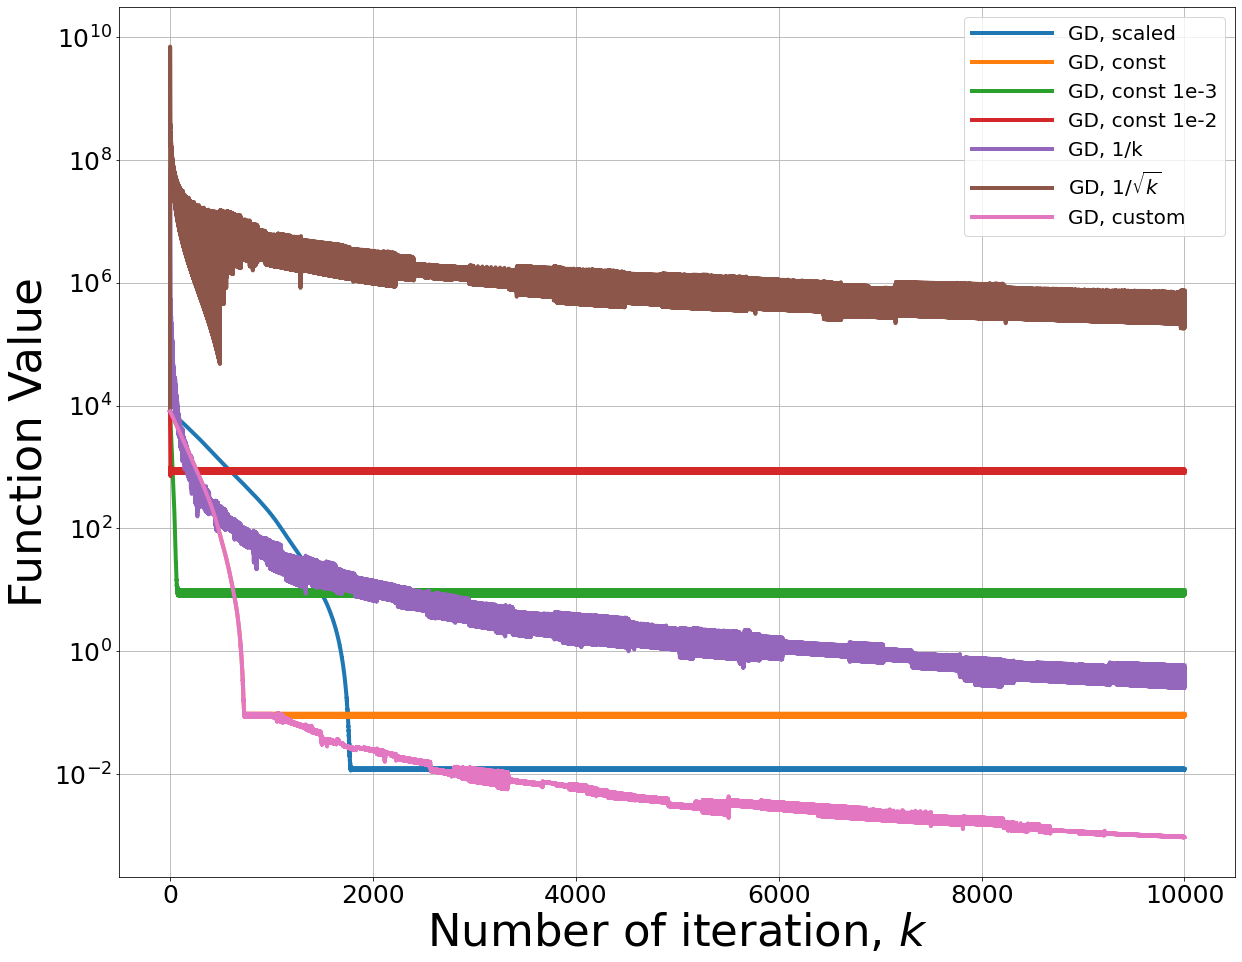

In [14]:
%matplotlib inline
plt.figure(figsize=(20, 16))
funcx = lambda x: 1/2 * np.linalg.norm(A @ x -b)**2
#funcx = lambda x: f(x)
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Function Value")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

In [15]:
f = lambda x: 0.5 * np.linalg.norm(A.dot(x) - b)**2
gradf = lambda x: A.T.dot(A.dot(x) - b)

In [16]:
methods = [SubgradMethod(ConstantStepSize(1e-3), name="GD, const")]
for method in methods:
    method.solve(x0, f, gradf, tol=1e-9, max_iter=10000)

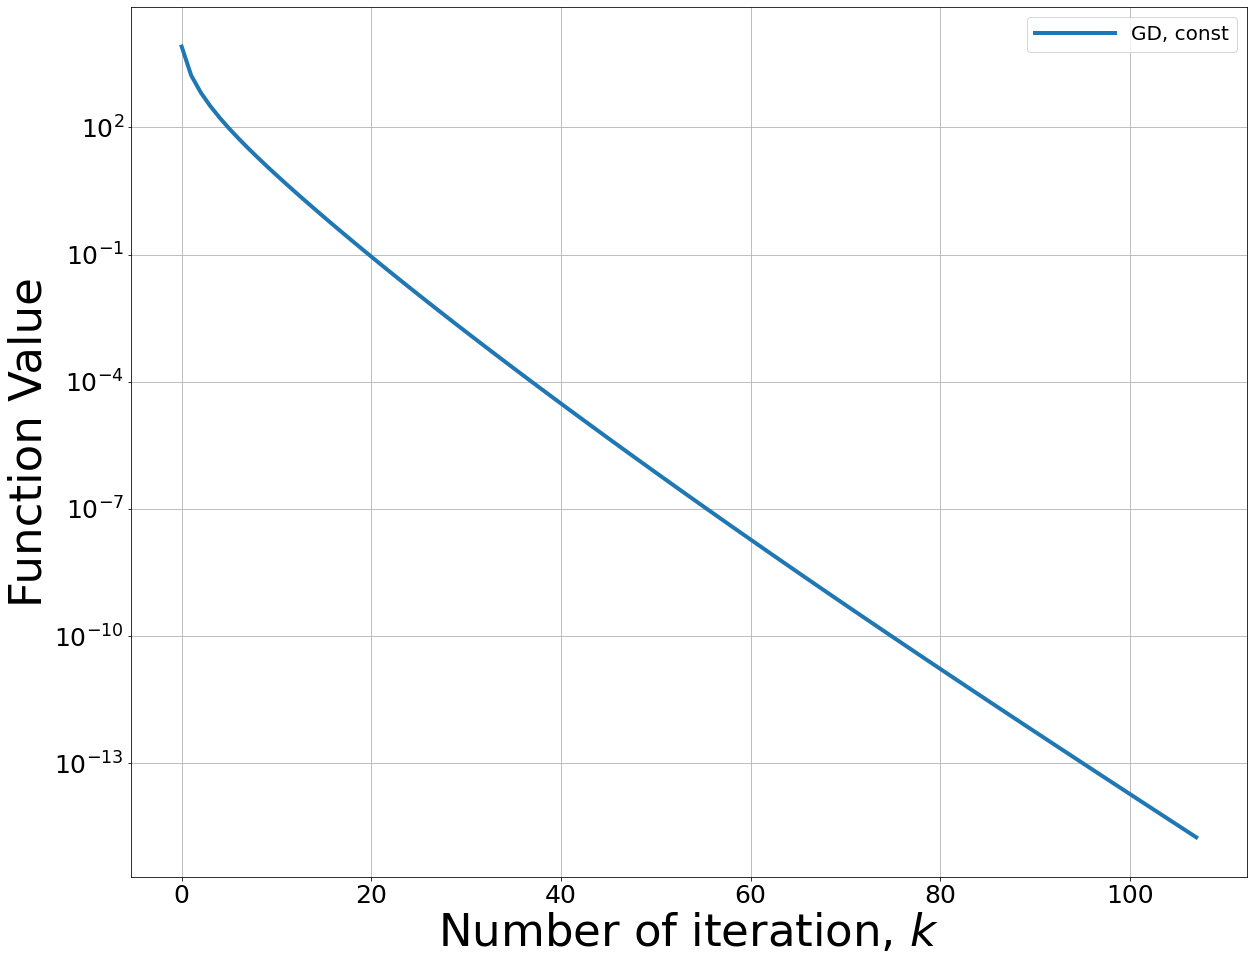

In [17]:
%matplotlib inline
plt.figure(figsize=(20, 16))
funcx = lambda x: 1/2 * np.linalg.norm(A @ x -b)**2
#funcx = lambda x: f(x)
for method in methods:
    xhistory = method.history
    times, values = parse_logs(method.history, ret_time=False, funcx=funcx)
    plt.semilogy(times, values, label=method.name)
plt.grid()
plt.ylabel(r"Function Value")
plt.xlabel(r"Number of iteration, $k$")
plt.legend()

## 1. Proximal method

Проксимальный оператор (prox-оператор):

$$prox_{\alpha f}(x) = \arg\min_u \left(f(u) + \frac{1}{2\alpha} \|u - x\|_2^2\right)$$

Шаг проксимального метода:

$$x_{k+1} = prox_{\alpha f}(x_k)$$


Если $h$ - $L$-гладкая функция, то $\forall x_k, x_{k+1}$

$$h(x_{k+1})\leq h(x_k) + \langle \nabla h_k, x_{k+1}-x_k \rangle + \frac{L}{2}\|x_k-x_{k+1}\|^2$$

## 2. Proximal gradient method (PGM) - look into black box

Пусть выпуклая оптимизируемая функция $f$ имеет вид

$$
f(x) = h(x) + g(x),
$$

где $h(x)$ выпуклая и дифференцируемая, $g(x)$ выпуклая функция, причем $g: \mathbb{R}^n \to \mathbb{R} \cup \{+\infty\}$

Тогда один шаг PGM:

$$
x_{k+1} = prox_{\alpha_k g} (x_k - \alpha_k h'(x_k))
$$

- Скорость сходимости $\mathcal{O}(1/k)$ для шага $\alpha_k \equiv \alpha \in (0, 1/L]$, где $L$ - константа Липшица градиента $h'$
- Можно искать шаг $\alpha_k$ при помощи backtracking search:

$$h(x_{k+1})\leq h(x_k) + \langle \nabla h_k, x_{k+1}-x_k \rangle + \frac{1}{2\alpha_k}\|x_k-x_{k+1}\|^2$$

#### Частные случаи PGM

- Если $h \equiv 0$, то PGM есть проксимальный метод
- Если $g \equiv 0$, то PGM есть градиентный спуск 

$$I_D(x)=\begin{cases}0, x\in D,\\ +\infty, x\notin D\end{cases}$$

- Если $g=I_D(x)$, то PGM есть метод проекции градиента для задачи $\min_{x\in D} h(x)$

In [16]:
class ProxGM:
    def __init__(self, fix_lam=None, lam0=1, beta=0.5, return_history=True, name=None):
        self.name = name
        self.return_history = return_history
        self.history = []
        self.lam0 = lam0
        self.fix_lam = fix_lam
        self.beta = beta
    
    def backtracking(self, x, f, gradf, g_prox):
        lam = self.lam0
        f_x = f(x)
        f_grad_x = gradf(x)
        z = g_prox(x - lam * f_grad_x, lam)
        while f(z) > f_x + np.sum(f_grad_x*(z - x)) + np.linalg.norm(z - x)**2 / (2 * lam):
            lam = lam * self.beta
            z = g_prox(x - lam * gradf(x), lam)
            self.lam0 = lam
            if lam <= 1e-9:
                break
        return z
    
    def solve(self, x0, f, gradf, g_prox, tol=1e-3, max_iter=10000):
        x = x0.copy()
        self.history = [(x, time.time())]
        for i in range(max_iter):
            if self.fix_lam is None:
                x = self.backtracking(x, f, gradf, g_prox)
            else:
                x_ = x - self.fix_lam * gradf(x)
                x = g_prox(x_, self.fix_lam)
            self.history.append((x, time.time()))
        return x

## 3. Accelerated proximal gradient method

\begin{align*}
& y_{k+1} = x_k + w_k (x_k - x_{k-1})\\
& x_{k+1} = prox_{\alpha_k g} (y_{k+1} - \alpha_k h'(y_{k+1}))
\end{align*}

- $\{w_k\}$ специальная последовательность, выбранная для ускорения, например,, $w_k = \frac{k}{k+3}$
- Backtracking может быть полезен при выборе $\alpha_k$
- Скорость сходимости $\mathcal{O}(1/k^2)$

Последовательность w_k:

$$t_{k} = \frac{1+\sqrt{1+4t_{k-1}^2}}{2}$$

$$\omega_k = \frac{t_{k-1}-1}{t_{k}}$$

In [17]:
class AccProxGM(ProxGM):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def solve(self, x0, f, gradf, g_prox, tol=1e-3, max_iter=10000):
        x = x0.copy()
        x_prev = x.copy()
        self.history = [(x, time.time())]
        t_prev = 1
        t_next = (1 + np.sqrt(1 + 4 * t_prev**2)) / 2.
        for i in range(max_iter):
            w = (t_prev - 1) / t_next
            x, x_prev = x + w * (x - x_prev), x
            t_prev = t_next
            t_next = (1 + np.sqrt(1 + 4 * t_prev**2)) / 2.
            if self.fix_lam is None:
                x = self.backtracking(x, f, gradf, g_prox)
            else:
                x_ = x - self.fix_lam * gradf(x)
                x = g_prox(x_, self.fix_lam)
            self.history.append((x, time.time()))
        return x

## 4. Эксперименты: Lasso

LASSO (Least Absolute Shrinkage and Selection Operator):

$$
\min_x \frac{1}{2}\|Ax - y \|^2_2 + \gamma \|x\|_1
$$

- $h(x) = \frac{1}{2}\|Ax - y \|^2_2$
- $g(x) = \gamma \|x\|_1$

$$\min_u \|u\|_1 + \frac{1}{2\alpha \gamma} \|u-x\|^2_2$$

- $\|x\|_1 = |x_1| + \ldots + |x_n|$
- Separable sum
- $prox_{\alpha \|x\|_1} (x)_i = prox_{\alpha |\cdot|}(x_i)$
- $prox_{\alpha |\cdot|} (x_i) = \arg\min_u (|u| + 1/(2\alpha)\|x_i - u\|^2_2)$
- Analytical solution
$$ 
prox_{\alpha |\cdot|} (x_i) = \begin{cases} x_i - \alpha & x_i \geq \alpha  \\ 0 & |x_i| \leq \alpha \\ x_i + \alpha & x_i \leq -\alpha \end{cases}
$$
- Vectorized form
$$
prox_{\alpha \|x\|_1} (x) = \text{sign}(x)(|x| - \alpha)_+, \; |x| = (|x_1|, \ldots, |x_n|)
$$

####  (F)ISTA

- Proximal gradient method for Lasso problem is known as ISTA (Iterative shrinkage-thresholding algorithm)
- Fast proximal gradient is known as FISTA (Fast ISTA)

In [18]:
m = 500
n = 2500
np.random.seed(1)
A = np.random.rand(m, n)
A = skprep.normalize(A, norm="l2", axis=0)
L = np.linalg.eigvalsh(A.T.dot(A)).max()
x_true = np.random.randn(n)
x_true[np.random.rand(n) < 0.96] = 0
print("Number of nonzeros in x_true = {}".format(np.sum(x_true != 0)))
v = 9e-2 * np.random.randn(m)
y = A.dot(x_true) + v
gamma_max = np.linalg.norm(A.T.dot(y), ord=np.inf)
gamma = 0.1 * gamma_max
print("Gamma = {}".format(gamma))
print("S2N ratio = {}".format(np.linalg.norm(A.dot(x_true))**2 / np.linalg.norm(v)**2))
x0 = np.random.rand(n)

Number of nonzeros in x_true = 84
Gamma = 1.2180047577704631
S2N ratio = 46.16567095285224


In [19]:
F = lambda x: np.linalg.norm(A.dot(x) - y)**2 / 2 + gamma * np.sum(np.abs(x))
subgradF = lambda x: A.T.dot(A.dot(x) - y) + gamma * np.sign(x)

f = lambda x: np.linalg.norm(A.dot(x) - y)**2 / 2
gradf = lambda x: A.T.dot(A.dot(x) - y)

g_prox = lambda h, alpha: np.sign(h) * np.maximum(np.abs(h) - alpha * gamma, 0)

In [20]:
num_iter = 2000
methods = []

In [21]:
method = SubgradMethod(ConstantStepSize(5e-4), name="Subgradient Method")
x_subgrad = method.solve(x0, F, subgradF, tol=0, max_iter=num_iter)
methods.append(method)
print(method.name)
print("\tNumber nonzeros in x* = {}".format(np.sum(x_subgrad != 0)))
print("\tf^* = {}".format(F(x_subgrad)))

method = ProxGM(name="ProxGM")
x = method.solve(x0, f, gradf, g_prox, max_iter=num_iter)
methods.append(method)
print(method.name)
print("\tNumber nonzeros in x* = {}".format(np.sum(x != 0)))
print("\tf* = {}".format(F(x)))
method = AccProxGM(fix_lam=None, name="AccProxGM")
x_acc = method.solve(x0, f, gradf, g_prox, max_iter=num_iter)
methods.append(method)

print(method.name)
print("\tNumber nonzeros in x* = {}".format(np.sum(x_acc != 0)))
print("\tf* = {}".format(F(x_acc)))

Subgradient Method
	Number nonzeros in x* = 2500
	f^* = 26.31335175341896
ProxGM
	Number nonzeros in x* = 309
	f* = 26.164257420296543
AccProxGM
	Number nonzeros in x* = 31
	f* = 24.484173300433852


In [36]:
np.sum(np.abs(x_subgrad)>=1e-2), F(x_subgrad * (np.abs(x_subgrad)>1e-2))

(213, 26.93935433851559)

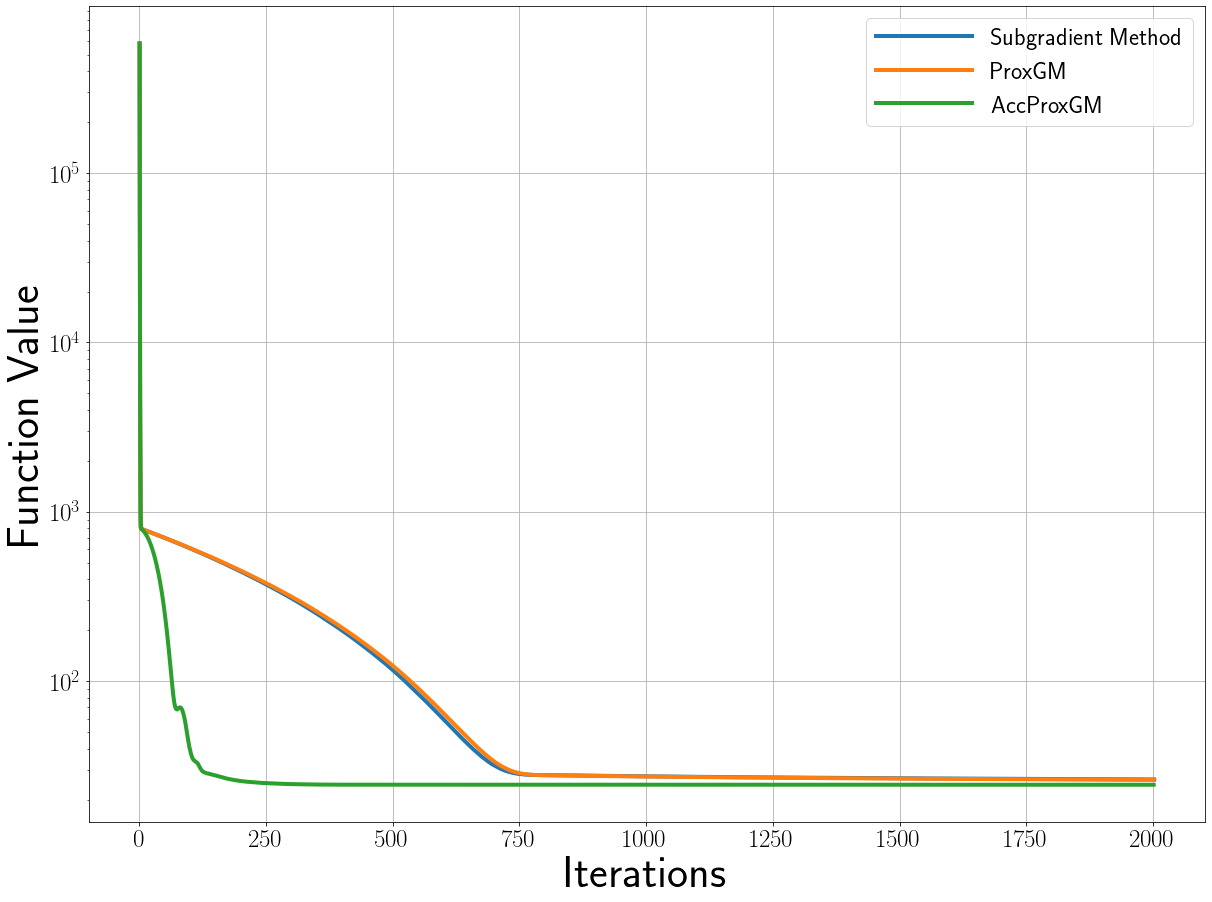

In [22]:
%matplotlib inline
plt.rc("text", usetex=True)
plt.figure(figsize=(20, 15))

for method in methods:
    hist = [F(x) for x, _ in method.history]
    plt.semilogy(range(1, len(hist) + 1), hist, label=method.name)
plt.grid()
plt.xlabel("Iterations")
plt.ylabel("Function Value")
plt.legend(loc="best", fontsize=24)